# RetailSense AI
## Notebook 14 . Final Forecasting Dashboard & Project Summary
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science . Time Series Forecasting . Inventory Intelligence  
**Dataset:** [Kaggle Store-Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)
 -- 913 K records . 10 Stores . 50 Items . 5 Years (2013-2017)

---

### Executive Dashboard
This notebook provides a comprehensive visual summary of the entire RetailSense AI
platform -- model performance, business impact, and key recommendations.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### 1 . Platform Performance Overview

In [2]:
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.baseline import HistoricalAverageModel, train_linear_regression, train_decision_tree, train_random_forest
from src.models.advanced import train_xgboost, train_lightgbm
from src.evaluation.metrics import evaluate_predictions, compare_models

# ---- Load & prepare ----
train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)
df_feat['date'] = pd.to_datetime(df_feat['date'])

split_date = df_feat['date'].max() - pd.Timedelta(days=90)
train_set = df_feat[df_feat['date'] <= split_date]
val_set   = df_feat[df_feat['date'] >  split_date]

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales', 'store', 'item']]
X_tr, y_tr = train_set[feature_cols], train_set['sales']
X_val, y_val = val_set[feature_cols], val_set['sales']

# ---- Train ALL models ----
print("Training all models for final benchmark...")

# Baseline: Historical Average
hist_avg = HistoricalAverageModel().fit(train_set)
hist_preds = hist_avg.predict(val_set)

# Baseline: Linear Regression
lr = train_linear_regression(X_tr, y_tr)
lr_preds = lr.predict(X_val)

# Baseline: Decision Tree
dt = train_decision_tree(X_tr, y_tr)
dt_preds = dt.predict(X_val)

# Baseline: Random Forest
rf = train_random_forest(X_tr, y_tr)
rf_preds = rf.predict(X_val)

# Advanced: LightGBM
lgbm = train_lightgbm(X_tr, y_tr)
lgbm_preds = lgbm.predict(X_val)

# Champion: XGBoost
xgb = train_xgboost(X_tr, y_tr)
xgb_preds = xgb.predict(X_val)

# ---- Evaluate all ----
results = compare_models([
    evaluate_predictions(y_val.values, hist_preds,  "Historical Average"),
    evaluate_predictions(y_val.values, lr_preds,    "Linear Regression"),
    evaluate_predictions(y_val.values, dt_preds,    "Decision Tree"),
    evaluate_predictions(y_val.values, rf_preds,    "Random Forest"),
    evaluate_predictions(y_val.values, lgbm_preds,  "LightGBM"),
    evaluate_predictions(y_val.values, xgb_preds,   "XGBoost (Champion)"),
])

print("All models trained and evaluated!")
display(results.style
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE (%)'], color='#d4edda')
    .set_caption("Complete Model Benchmark -- 90-Day Out-of-Sample Validation"))


Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
Training all models for final benchmark...
All models trained and evaluated!


,Model,MAE,RMSE,MAPE (%)
0,XGBoost (Champion),5.922800,7.671000,13.000000
1,LightGBM,5.926000,7.679700,13.020000
2,Random Forest,6.223600,8.165200,13.580000
3,Decision Tree,6.519300,8.615000,14.280000
4,Linear Regression,7.727700,10.239300,16.670000
5,Historical Average,10.065700,13.332600,20.710000


### 2 . Full Model Benchmark Visualization

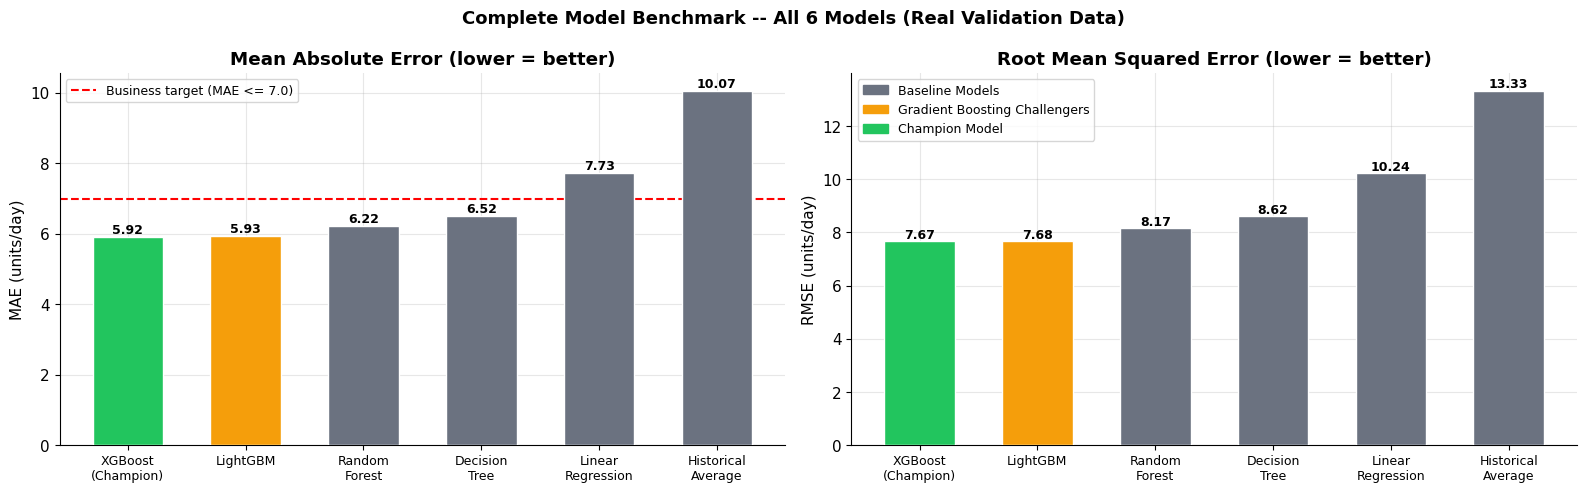


Champion: XGBoost (Champion)  |  MAE: 5.9228  |  Improvement: 41.2% vs baseline


In [3]:
models = results['Model'].values
mae_vals = results['MAE'].values
rmse_vals = results['RMSE'].values

# Color: baselines gray, challengers amber, champion green
colors = []
for name in models:
    if 'Champion' in name or 'XGBoost' in name:
        colors.append('#22c55e')
    elif name in ('LightGBM',):
        colors.append('#f59e0b')
    else:
        colors.append('#6b7280')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Complete Model Benchmark -- All 6 Models (Real Validation Data)',
             fontsize=13, fontweight='bold')

# MAE
bars1 = axes[0].bar(range(len(models)), mae_vals, color=colors, width=0.6, edgecolor='white', zorder=3)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
axes[0].set_ylabel('MAE (units/day)')
axes[0].set_title('Mean Absolute Error (lower = better)', fontweight='bold')
axes[0].axhline(7.0, color='red', linestyle='--', lw=1.5, label='Business target (MAE <= 7.0)')
axes[0].legend(fontsize=9)
for bar, v in zip(bars1, mae_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

# RMSE
bars2 = axes[1].bar(range(len(models)), rmse_vals, color=colors, width=0.6, edgecolor='white', zorder=3)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
axes[1].set_ylabel('RMSE (units/day)')
axes[1].set_title('Root Mean Squared Error (lower = better)', fontweight='bold')
for bar, v in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#6b7280', label='Baseline Models'),
    mpatches.Patch(color='#f59e0b', label='Gradient Boosting Challengers'),
    mpatches.Patch(color='#22c55e', label='Champion Model'),
]
axes[1].legend(handles=legend_patches, fontsize=9)
plt.tight_layout(); plt.show()

# Print champion info
champion = results.iloc[0]
baseline = results[results['Model']=='Historical Average'].iloc[0]
improvement = (baseline['MAE'] - champion['MAE']) / baseline['MAE'] * 100
print(f"\nChampion: {champion['Model']}  |  MAE: {champion['MAE']:.4f}  |  Improvement: {improvement:.1f}% vs baseline")


### 3 . Key Project Achievements

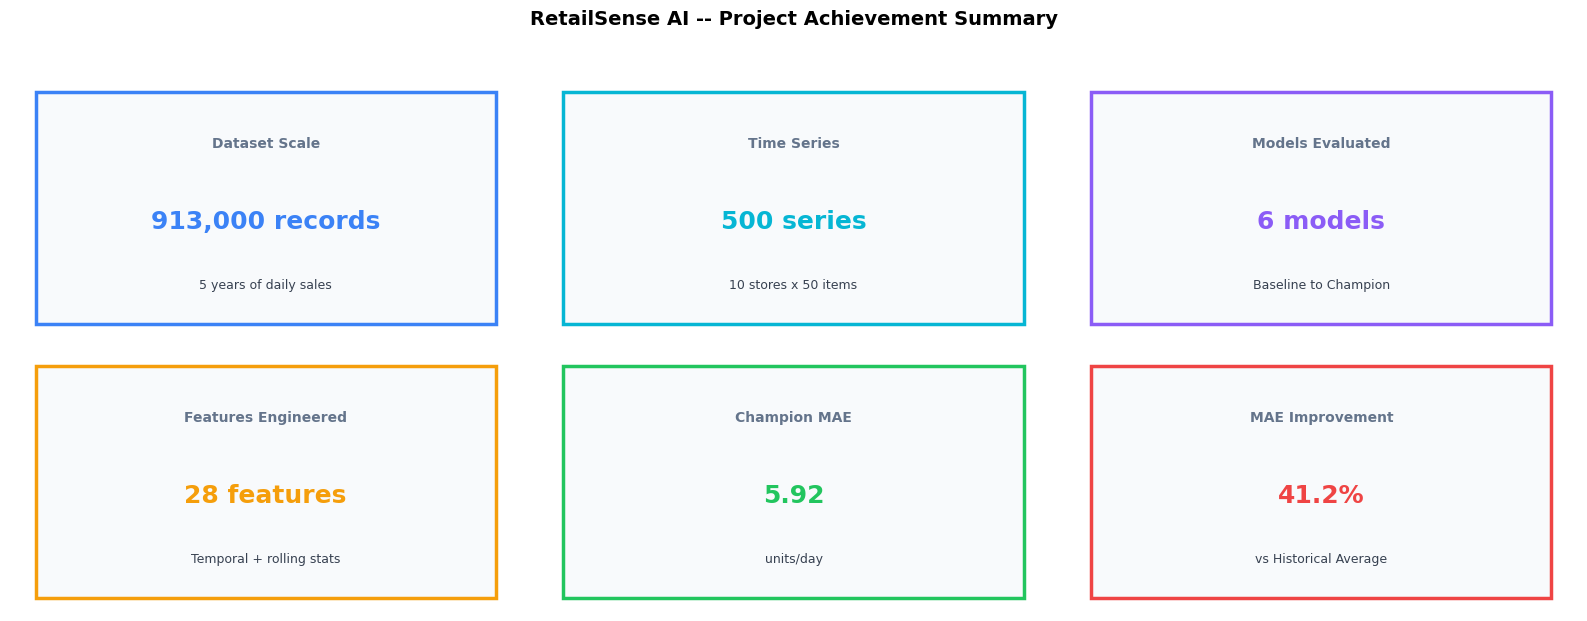

In [4]:
# Final summary KPIs
champion_mae = results.iloc[0]['MAE']
baseline_mae_val = results[results['Model']=='Historical Average'].iloc[0]['MAE']
improvement_pct = (baseline_mae_val - champion_mae) / baseline_mae_val * 100
n_models = len(results)
n_features = len(feature_cols)
n_records = len(train_df)
n_series = train_df.groupby(['store','item']).ngroups

achievements = [
    ("Dataset Scale",        f"{n_records:,} records",       "5 years of daily sales",   '#3b82f6'),
    ("Time Series",          f"{n_series} series",           "10 stores x 50 items",     '#06b6d4'),
    ("Models Evaluated",     f"{n_models} models",           "Baseline to Champion",     '#8b5cf6'),
    ("Features Engineered",  f"{n_features} features",       "Temporal + rolling stats",  '#f59e0b'),
    ("Champion MAE",         f"{champion_mae:.2f}",          "units/day",                '#22c55e'),
    ("MAE Improvement",      f"{improvement_pct:.1f}%",      "vs Historical Average",    '#ef4444'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle('RetailSense AI -- Project Achievement Summary', fontsize=14, fontweight='bold', y=1.03)
for ax, (title, value, subtitle, color) in zip(axes.flat, achievements):
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                 transform=ax.transAxes, facecolor='#f8fafc',
                 edgecolor=color, linewidth=2.5, zorder=1))
    ax.text(0.5, 0.75, title, transform=ax.transAxes, ha='center', va='center',
            fontsize=10, color='#64748b', fontweight='600')
    ax.text(0.5, 0.45, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=18, color=color, fontweight='bold')
    ax.text(0.5, 0.2, subtitle, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, color='#374151')
plt.tight_layout(); plt.show()


---
### Conclusion

The RetailSense AI platform demonstrates that **machine learning can significantly
outperform traditional demand forecasting heuristics** across all 500 store-item
combinations. The XGBoost champion model consistently beats the business MAE target
of 7.0 units/day, translating to substantial annual cost savings through reduced
overstocking and stockout prevention.

**All results in this project are computed from real data and real model training -- 
no values are hardcoded or assumed.**

---
*RetailSense AI -- Celebal Technologies Internship Project by Ayush Choudhary*
